In [8]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

sys.path.append('../scripts')
sys.path.append('../')

In [9]:
from power_grid_forecasting import (
    NaiveModel, 
    StatisticalModel,
    RandomForestModel,
    TemporalGNN,
    construct_enhanced_graph_sequence,
    train_voltage_predictor
)

In [10]:
# Define a function to run the experiment
def run_power_grid_forecasting_experiment(builder, small_experiment=False):
    """
    Runs a complete experiment for power grid forecasting using multiple models.
    
    Args:
        builder: PandaPowerFlowBuilder instance
        small_experiment: If True, use a smaller subset of data and simpler configuration
        
    Returns:
        Dictionary with evaluation results and trained models
    """
    # Configuration based on experiment size
    if small_experiment:
        look_back = 12  # Use fewer historical timesteps
        forecast_horizon = 12  # Predict fewer steps ahead
        epochs = 20  # Fewer training epochs
        print("Running small experiment configuration")
    else:
        look_back = 24  # Full day of historical data
        forecast_horizon = 24  # Predict full day ahead
        epochs = 50
        print("Running full experiment configuration")
    
    stride = forecast_horizon  # Non-overlapping sequences
    
    # Construct dataset
    print("Constructing dataset...")
    X_data, y_data, scalers, node_ids = construct_enhanced_graph_sequence(
        builder, look_back=look_back, forecast_horizon=forecast_horizon, stride=stride)
    
    print(f"Created {len(X_data)} samples for training and prediction")
    
    # Split into train, validation, and test sets
    train_size = int(0.7 * len(X_data))
    val_size = int(0.15 * len(X_data))
    
    X_train = X_data[:train_size]
    y_train = y_data[:train_size]
    
    X_val = X_data[train_size:train_size+val_size]
    y_val = y_data[train_size:train_size+val_size]
    
    X_test = X_data[train_size+val_size:]
    y_test = y_data[train_size+val_size:]
    
    target_scaler = scalers['target_scaler']
    
    # Train all models
    models = {}
    
    # 1. Naive model
    print("\nTraining Naive model...")
    naive_model = NaiveModel(forecast_horizon=forecast_horizon)
    naive_model.fit(X_train, y_train)
    models['Naive'] = naive_model
    
    # 2. Statistical model (Exponential Smoothing)
    print("\nTraining Statistical model (Exponential Smoothing)...")
    stat_model = StatisticalModel(forecast_horizon=forecast_horizon, method='exp_smoothing')
    stat_model.fit(X_train, y_train)
    models['Statistical'] = stat_model
    
    # 3. Random Forest model
    print("\nTraining Random Forest model...")
    rf_model = RandomForestModel(forecast_horizon=forecast_horizon)
    rf_model.fit(X_train, y_train)
    models['RandomForest'] = rf_model
    
    # 4. GNN model
    print("\nTraining GNN model...")
    gnn_model = train_voltage_predictor(
        X_train, y_train, X_val, y_val, 
        forecast_horizon=forecast_horizon, 
        epochs=epochs
    )
    models['GNN'] = gnn_model
    
    # Evaluate all models
    print("\nEvaluating all models...")
    evaluation_results = evaluate_models(
        models, X_test, y_test, 
        target_scaler=target_scaler,
        node_names=node_ids
    )
    
    # Print overall results
    print("\n===== OVERALL RESULTS =====")
    for model_name, results in evaluation_results.items():
        print(f"\n{model_name} Model:")
        print(f"  MAE: {results['overall']['mae']:.4f}")
        print(f"  RMSE: {results['overall']['rmse']:.4f}")
        print(f"  R²: {results['overall']['r2']:.4f}")
    
    # Create a horizon performance comparison
    print("\n===== FORECAST HORIZON PERFORMANCE =====")
    for h in range(min(forecast_horizon, 5)):  # Show first 5 horizons
        print(f"\nHorizon {h+1}:")
        for model_name, results in evaluation_results.items():
            h_metrics = results['by_horizon'][h]
            print(f"  {model_name}: MAE={h_metrics['mae']:.4f}, RMSE={h_metrics['rmse']:.4f}")
    
    # Return results dictionary
    results = {
        'models': models,
        'evaluation': evaluation_results,
        'scalers': scalers,
        'node_ids': node_ids,
        'config': {
            'look_back': look_back,
            'forecast_horizon': forecast_horizon,
            'stride': stride
        }
    }
    
    return results

# Define the missing evaluation function
def predict_gnn(model, X_test, target_scaler=None):
    """
    Makes voltage predictions using the trained GNN model.
    
    Args:
        model: Trained TemporalGNN model
        X_test: Test sequences
        target_scaler: Scaler used for target normalization
        
    Returns:
        Predicted voltage magnitudes for all forecast horizons
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(0, len(X_test), 1):  # Process one at a time to avoid memory issues
            batch_X = [X_test[i]]
            
            # Prepare batch
            x, edge_index, edge_attr = prepare_batch_for_model(batch_X, device)
            
            # Forward pass
            out = model(x, edge_index, edge_attr)
            pred = out.cpu().numpy().squeeze()
            
            # Inverse transform if scaler was used
            if target_scaler:
                # Reshape for each horizon and transform
                n_nodes, n_horizons = pred.shape
                pred_reshaped = pred.reshape(-1, 1)
                pred_reshaped = target_scaler.inverse_transform(pred_reshaped)
                pred = pred_reshaped.reshape(n_nodes, n_horizons)
                
            predictions.append(pred)
    
    return np.array(predictions)

def evaluate_models(models, X_test, y_test, target_scaler=None, node_names=None):
    """
    Evaluates multiple forecasting models on test data.
    
    Args:
        models: Dictionary of trained models
        X_test: Test sequences
        y_test: True target values
        target_scaler: Scaler used for target normalization
        node_names: List of node names for detailed reporting
        
    Returns:
        Dictionary of evaluation metrics for each model
    """
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import torch
    
    results = {}
    
    # Prepare true values
    y_true = np.array(y_test)
    if target_scaler:
        # Reshape for inverse transformation
        y_true_shape = y_true.shape
        y_true_flat = y_true.reshape(-1, 1)
        y_true_flat = target_scaler.inverse_transform(y_true_flat)
        y_true = y_true_flat.reshape(y_true_shape)
    
    # Evaluate each model
    for model_name, model in models.items():
        print(f"Evaluating {model_name}...")
        
        if model_name == 'GNN':
            # Use GNN-specific prediction function
            y_pred = predict_gnn(model, X_test, target_scaler)
        else:
            # Use predict method for other models
            y_pred = model.predict(X_test)
            
            # Inverse transform if necessary
            if target_scaler:
                y_pred_shape = y_pred.shape
                y_pred_flat = y_pred.reshape(-1, 1)
                y_pred_flat = target_scaler.inverse_transform(y_pred_flat)
                y_pred = y_pred_flat.reshape(y_pred_shape)
        
        # Calculate overall metrics across all nodes and horizons
        mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
        rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
        r2 = r2_score(y_true.flatten(), y_pred.flatten())
        
        # Calculate per-horizon metrics
        horizon_metrics = []
        n_horizons = y_true.shape[2] if len(y_true.shape) > 2 else y_true.shape[1]
        
        for h in range(n_horizons):
            h_true = y_true[:, :, h] if len(y_true.shape) > 2 else y_true[:, h]
            h_pred = y_pred[:, :, h] if len(y_pred.shape) > 2 else y_pred[:, h]
            
            h_mae = mean_absolute_error(h_true.flatten(), h_pred.flatten())
            h_rmse = np.sqrt(mean_squared_error(h_true.flatten(), h_pred.flatten()))
            
            horizon_metrics.append({
                'horizon': h + 1,
                'mae': h_mae,
                'rmse': h_rmse
            })
        
        # Calculate per-node metrics if node names are provided
        node_metrics = []
        if node_names:
            n_nodes = len(node_names)
            for n in range(n_nodes):
                n_true = y_true[:, n, :] if len(y_true.shape) > 2 else y_true[:, n]
                n_pred = y_pred[:, n, :] if len(y_pred.shape) > 2 else y_pred[:, n]
                
                n_mae = mean_absolute_error(n_true.flatten(), n_pred.flatten())
                n_rmse = np.sqrt(mean_squared_error(n_true.flatten(), n_pred.flatten()))
                
                node_metrics.append({
                    'node': node_names[n],
                    'mae': n_mae,
                    'rmse': n_rmse
                })
        
        # Compile results
        results[model_name] = {
            'overall': {
                'mae': mae,
                'rmse': rmse,
                'r2': r2
            },
            'by_horizon': horizon_metrics,
            'by_node': node_metrics
        }
    
    return results

# Load your builder object
save_dir = "../data/parsed/"
load_path = os.path.join(save_dir, "builder.pkl")

with open(load_path, "rb") as f:
    builder = pickle.load(f)

In [11]:
# Run the experiment
print("Starting power grid forecasting experiment...")
results = run_power_grid_forecasting_experiment(builder, small_experiment=True)

Starting power grid forecasting experiment...
Running small experiment configuration
Constructing dataset...
Building dataset with 8760 timestamps...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (358,) + inhomogeneous part.

Starting power grid forecasting experiment...
Running experiment with look_back=24, forecast_horizon=24, stride=24
Using a subset of 480 timestamps out of 8760
Extracting power grid data...
  Processing timestamp 0/480
  Processing timestamp 50/480
  Processing timestamp 100/480
  Processing timestamp 150/480
  Processing timestamp 200/480
  Processing timestamp 250/480
  Processing timestamp 300/480
  Processing timestamp 350/480
  Processing timestamp 400/480
  Processing timestamp 450/480
Data shapes:
  Voltage data: (480, 118)
  Load data: (480, 118, 2)
  Generation data: (480, 118, 2)
  Time features: (480, 6)
Normalizing data...
Created 19 sequences for training and evaluation
Train set: 13 sequences
Validation set: 2 sequences
Test set: 4 sequences

Training Naive model...

Training Mean model...

Training Linear Regression model...
Trained 1291 / 2832 possible models

Training Random Forest model...
Trained 1504 / 2832 possible models

Evaluating models...
Evaluating Naive mode

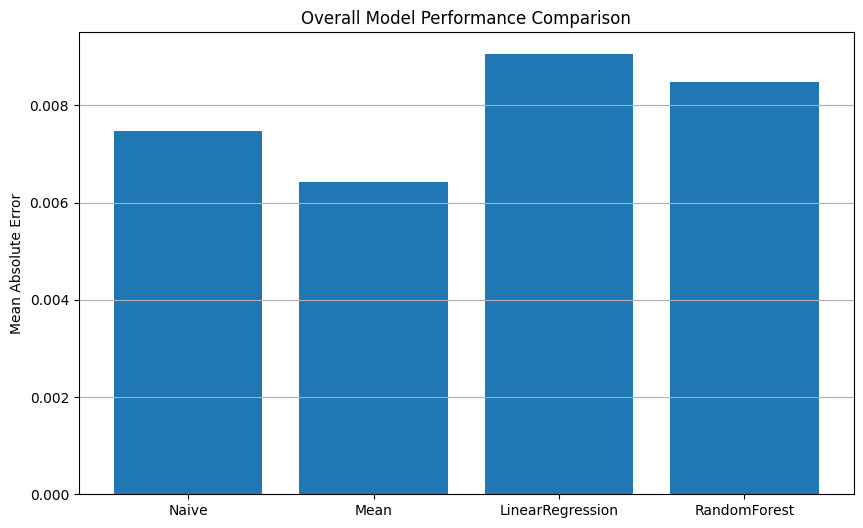

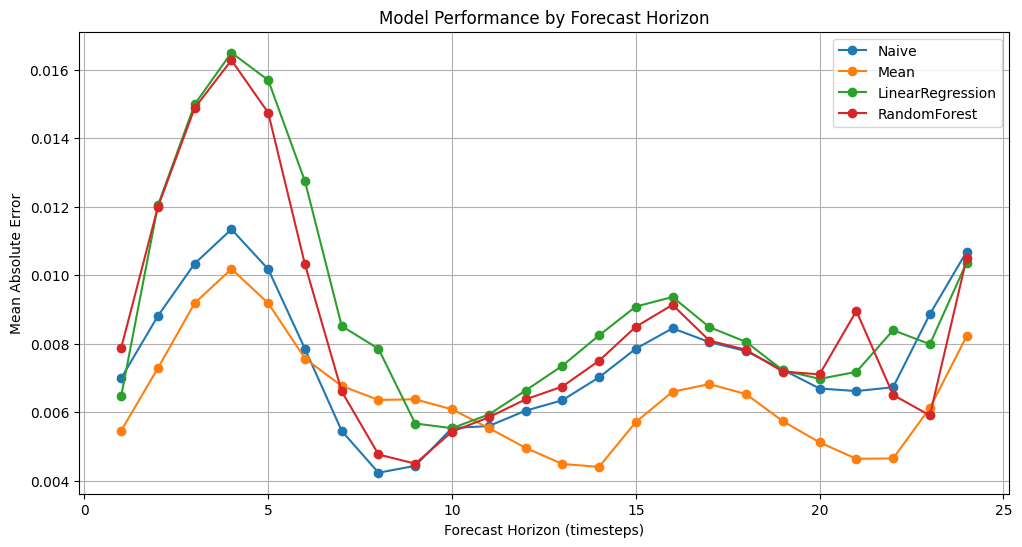

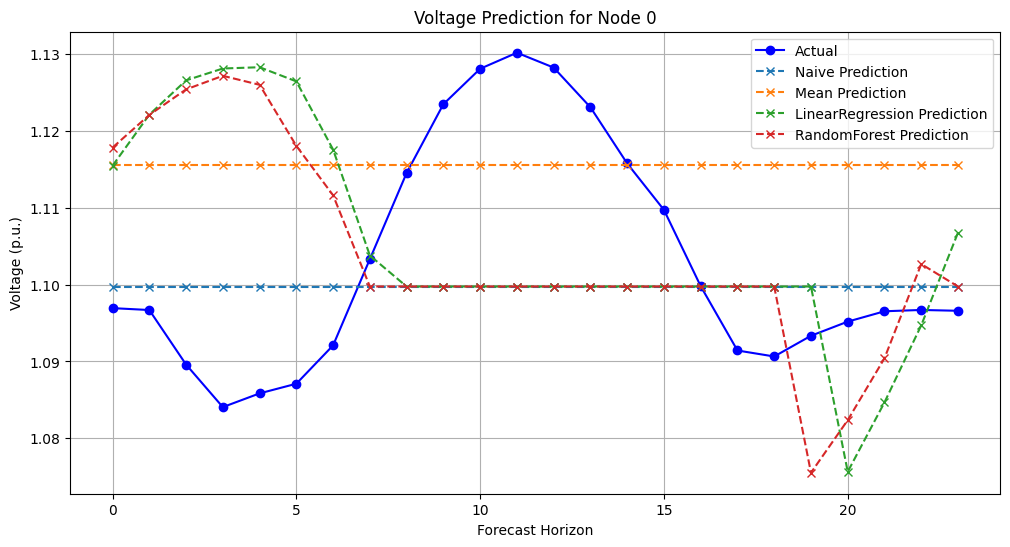


Results saved to ../data/parsed/extended_forecasting_results.pkl


In [12]:
# Extended Power Grid Forecasting Experiment

import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Add parent directory to path to find src module if needed
sys.path.append('../')
sys.path.append('../scripts')

# Define forecasting experiment with increased data
def grid_forecasting_experiment(builder, max_timestamps=480, use_subset=True):
    """
    A forecasting experiment that works with a larger subset of the data
    and focuses on basic but effective models.
    
    Args:
        builder: PandaPowerFlowBuilder instance
        max_timestamps: Maximum number of timestamps to use (480 by default)
        use_subset: If True, limit to max_timestamps
    """
    # Configuration
    look_back = 24     # One day of history
    forecast_horizon = 24  # One day of forecast
    stride = 24  # Non-overlapping windows
    
    print(f"Running experiment with look_back={look_back}, forecast_horizon={forecast_horizon}, stride={stride}")
    
    # Extract timestamps
    timestamps = builder.timestamps
    if use_subset and len(timestamps) > max_timestamps:
        timestamps = timestamps[:max_timestamps]
        print(f"Using a subset of {len(timestamps)} timestamps out of {len(builder.timestamps)}")
    else:
        print(f"Using all {len(timestamps)} timestamps")
    
    # Process the data with a simplified approach that avoids edge features
    voltage_data = []  # Voltage values for each timestep
    load_data = []     # Load values for each timestep
    gen_data = []      # Generation values for each timestep
    time_features = [] # Temporal features
    node_ids = []      # Bus IDs
    
    print("Extracting power grid data...")
    for t, ts in enumerate(timestamps):
        if t % 50 == 0:
            print(f"  Processing timestamp {t}/{len(timestamps)}")
        
        # Extract datetime features
        dt = datetime.strptime(ts, "%Y-%m-%d %H:%M:%S")
        hour_sin = np.sin(2 * np.pi * dt.hour / 24)
        hour_cos = np.cos(2 * np.pi * dt.hour / 24)
        day_sin = np.sin(2 * np.pi * dt.weekday() / 7)
        day_cos = np.cos(2 * np.pi * dt.weekday() / 7)
        month_sin = np.sin(2 * np.pi * dt.month / 12)
        month_cos = np.cos(2 * np.pi * dt.month / 12)
        time_features.append([hour_sin, hour_cos, day_sin, day_cos, month_sin, month_cos])
        
        # Run the model for this timestamp
        sample = builder.run(ts)
        
        # Extract bus IDs on first iteration
        if t == 0:
            node_ids = sorted(sample.bus.index)
            
        # Extract values for each bus
        vm_values = []  # Voltage magnitude
        load_p_values = []  # Active power load
        load_q_values = []  # Reactive power load
        gen_p_values = []  # Active power generation
        gen_q_values = []  # Reactive power generation
        
        for idx in node_ids:
            # Voltage values
            if idx in sample.res_bus.index:
                vm_values.append(float(sample.res_bus.loc[idx]['vm_pu']))
                
                # Initialize load and generation to zero
                load_p = 0.0
                load_q = 0.0
                gen_p = 0.0
                gen_q = 0.0
                
                # Add load contributions
                for load_idx, load in sample.load.iterrows():
                    if load['bus'] == idx:
                        load_p += float(load['p_mw'])
                        load_q += float(load['q_mvar'])
                
                # Add generation contributions
                for gen_idx, gen in sample.gen.iterrows():
                    if gen['bus'] == idx:
                        if gen_idx in sample.res_gen.index:
                            gen_p += float(sample.res_gen.loc[gen_idx]['p_mw'])
                            gen_q += float(sample.res_gen.loc[gen_idx]['q_mvar'])
                
                load_p_values.append(load_p)
                load_q_values.append(load_q)
                gen_p_values.append(gen_p)
                gen_q_values.append(gen_q)
            else:
                # Default values if bus not found
                vm_values.append(1.0)
                load_p_values.append(0.0)
                load_q_values.append(0.0)
                gen_p_values.append(0.0)
                gen_q_values.append(0.0)
                
        voltage_data.append(np.array(vm_values))
        load_data.append(np.array([load_p_values, load_q_values]).T)  # Shape: (n_nodes, 2)
        gen_data.append(np.array([gen_p_values, gen_q_values]).T)  # Shape: (n_nodes, 2)
    
    voltage_data = np.array(voltage_data)
    load_data = np.array(load_data)
    gen_data = np.array(gen_data)
    time_features = np.array(time_features)
    
    print(f"Data shapes:")
    print(f"  Voltage data: {voltage_data.shape}")
    print(f"  Load data: {load_data.shape}")
    print(f"  Generation data: {gen_data.shape}")
    print(f"  Time features: {time_features.shape}")
    
    # Normalize the data
    print("Normalizing data...")
    voltage_scaler = StandardScaler()
    load_scaler = StandardScaler()
    gen_scaler = StandardScaler()
    
    # Reshape for scalers
    voltage_data_norm = voltage_scaler.fit_transform(voltage_data.reshape(-1, 1)).reshape(voltage_data.shape)
    load_data_flat = load_data.reshape(-1, load_data.shape[-1])
    load_data_norm = load_scaler.fit_transform(load_data_flat).reshape(load_data.shape)
    gen_data_flat = gen_data.reshape(-1, gen_data.shape[-1])
    gen_data_norm = gen_scaler.fit_transform(gen_data_flat).reshape(gen_data.shape)
    
    # Create sequences for multi-step forecasting
    X_data = []
    y_data = []
    
    for t in range(0, len(timestamps) - look_back - forecast_horizon + 1, stride):
        # Input sequence: past values
        x_seq = {
            'voltage': voltage_data_norm[t:t+look_back],
            'load': load_data_norm[t:t+look_back],
            'gen': gen_data_norm[t:t+look_back],
            'time_features': time_features[t:t+look_back],
            'voltage_raw': voltage_data[t:t+look_back]  # Keep raw values for naive models
        }
        
        # Target: future voltage values (normalized)
        y_seq = voltage_data_norm[t+look_back:t+look_back+forecast_horizon]
        
        X_data.append(x_seq)
        y_data.append(y_seq)
    
    print(f"Created {len(X_data)} sequences for training and evaluation")
    
    # Split into train, validation, and test sets
    train_size = int(0.7 * len(X_data))
    val_size = int(0.15 * len(X_data))
    
    X_train = X_data[:train_size]
    y_train = y_data[:train_size]
    X_val = X_data[train_size:train_size+val_size]
    y_val = y_data[train_size:train_size+val_size]
    X_test = X_data[train_size+val_size:]
    y_test = y_data[train_size+val_size:]
    
    print(f"Train set: {len(X_train)} sequences")
    print(f"Validation set: {len(X_val)} sequences")
    print(f"Test set: {len(X_test)} sequences")
    
    # Train and evaluate models
    models = {}
    
    # 1. Naive model (persistence forecast)
    print("\nTraining Naive model...")
    models['Naive'] = train_naive_model(forecast_horizon)
    
    # 2. Mean model (average of historical values)
    print("\nTraining Mean model...")
    models['Mean'] = train_mean_model(forecast_horizon)
    
    # 3. Machine learning models if available
    try:
        from sklearn.ensemble import RandomForestRegressor
        from sklearn.linear_model import LinearRegression
        
        print("\nTraining Linear Regression model...")
        models['LinearRegression'] = train_ml_model(
            X_train, y_train, X_val, y_val, 
            model_type='linear', 
            forecast_horizon=forecast_horizon,
            n_nodes=voltage_data.shape[1]
        )
        
        print("\nTraining Random Forest model...")
        models['RandomForest'] = train_ml_model(
            X_train, y_train, X_val, y_val, 
            model_type='rf', 
            forecast_horizon=forecast_horizon,
            n_nodes=voltage_data.shape[1]
        )
    except Exception as e:
        print(f"Skipping ML models due to error: {str(e)}")
    
    # Evaluate all models
    print("\nEvaluating models...")
    results = {}
    
    for name, model in models.items():
        print(f"Evaluating {name} model...")
        
        # Make predictions
        y_pred = predict_model(model, X_test, name)
        
        # Convert predictions back to original scale for evaluation
        if name not in ['Naive', 'Mean']:  # These models already use raw values
            y_pred_shape = y_pred.shape
            y_pred = voltage_scaler.inverse_transform(
                y_pred.reshape(-1, 1)).reshape(y_pred_shape)
        
        # Similarly transform the ground truth
        y_test_raw = []
        for i, x in enumerate(X_test):
            y_horizon = voltage_data[
                len(X_train) + len(X_val) + i + look_back:
                len(X_train) + len(X_val) + i + look_back + forecast_horizon
            ]
            y_test_raw.append(y_horizon)
        y_test_raw = np.array(y_test_raw)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test_raw.flatten(), y_pred.flatten())
        rmse = np.sqrt(mean_squared_error(y_test_raw.flatten(), y_pred.flatten()))
        
        results[name] = {
            'mae': mae,
            'rmse': rmse,
            'predictions': y_pred
        }
        
        print(f"  MAE: {mae:.6f}")
        print(f"  RMSE: {rmse:.6f}")
    
    # Plot comparison of overall performance
    plt.figure(figsize=(10, 6))
    
    model_names = list(results.keys())
    mae_values = [results[name]['mae'] for name in model_names]
    
    plt.bar(model_names, mae_values)
    plt.ylabel('Mean Absolute Error')
    plt.title('Overall Model Performance Comparison')
    plt.grid(axis='y')
    
    # Plot comparison by forecast horizon
    plt.figure(figsize=(12, 6))
    
    for name, result in results.items():
        # Calculate MAE for each horizon
        mae_by_horizon = []
        for h in range(forecast_horizon):
            horizon_mae = mean_absolute_error(
                np.array([y[h] for y in y_test_raw]).flatten(), 
                np.array([p[h] for p in result['predictions']]).flatten()
            )
            mae_by_horizon.append(horizon_mae)
        
        plt.plot(range(1, forecast_horizon + 1), mae_by_horizon, marker='o', label=name)
    
    plt.xlabel('Forecast Horizon (timesteps)')
    plt.ylabel('Mean Absolute Error')
    plt.title('Model Performance by Forecast Horizon')
    plt.legend()
    plt.grid(True)
    
    return {
        'models': models,
        'results': results,
        'node_ids': node_ids,
        'data': {
            'X_train': X_train,
            'y_train': y_train,
            'X_val': X_val,
            'y_val': y_val,
            'X_test': X_test,
            'y_test': y_test_raw
        },
        'scalers': {
            'voltage': voltage_scaler,
            'load': load_scaler,
            'gen': gen_scaler
        }
    }

# Model classes and training functions

class NaiveModel:
    """Persistence forecast model"""
    def __init__(self, forecast_horizon):
        self.forecast_horizon = forecast_horizon
    
    def predict(self, x):
        # Use the last observed voltage value for all future timesteps
        last_values = x['voltage_raw'][-1]
        return np.tile(last_values, (self.forecast_horizon, 1))

class MeanModel:
    """Mean forecast model"""
    def __init__(self, forecast_horizon):
        self.forecast_horizon = forecast_horizon
    
    def predict(self, x):
        # Use the mean of historical values for all future timesteps
        mean_values = np.mean(x['voltage_raw'], axis=0)
        return np.tile(mean_values, (self.forecast_horizon, 1))

class MLModel:
    """Machine learning model with separate model for each node and horizon"""
    def __init__(self, forecast_horizon, n_nodes, models=None):
        self.forecast_horizon = forecast_horizon
        self.n_nodes = n_nodes
        self.models = models or {}  # Dictionary of models indexed by (node, horizon)
    
    def predict(self, x):
        # Extract features
        features = self._extract_features(x)
        
        # Make predictions for each node and horizon
        predictions = np.zeros((self.forecast_horizon, self.n_nodes))
        
        for node in range(self.n_nodes):
            for horizon in range(self.forecast_horizon):
                if (node, horizon) in self.models:
                    # Use the trained model
                    pred = self.models[(node, horizon)].predict([features])[0]
                    predictions[horizon, node] = pred
                else:
                    # Fallback to last known value
                    predictions[horizon, node] = x['voltage'][-1, node]
        
        return predictions
    
    def _extract_features(self, x):
        """Extract features for prediction"""
        # Use voltage history, load/gen at last timestep, and time features
        voltage_history = x['voltage'].flatten()
        last_load = x['load'][-1].flatten()
        last_gen = x['gen'][-1].flatten()
        last_time = x['time_features'][-1]
        
        return np.concatenate([voltage_history, last_load, last_gen, last_time])

def train_naive_model(forecast_horizon):
    """Create a naive persistence forecast model"""
    return NaiveModel(forecast_horizon)

def train_mean_model(forecast_horizon):
    """Create a mean forecast model"""
    return MeanModel(forecast_horizon)

def train_ml_model(X_train, y_train, X_val, y_val, model_type, forecast_horizon, n_nodes):
    """Train ML models for each node and horizon"""
    if model_type == 'linear':
        from sklearn.linear_model import LinearRegression
        ModelClass = LinearRegression
    elif model_type == 'rf':
        from sklearn.ensemble import RandomForestRegressor
        ModelClass = lambda: RandomForestRegressor(n_estimators=50, random_state=42)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    # Train a separate model for each node and horizon
    models = {}
    
    # Extract features for training
    X_features = [_extract_ml_features(x) for x in X_train]
    X_val_features = [_extract_ml_features(x) for x in X_val]
    
    for node in range(n_nodes):
        for horizon in range(forecast_horizon):
            # Extract target values for this node and horizon
            y_node_horizon = np.array([y[horizon, node] for y in y_train])
            y_val_node_horizon = np.array([y[horizon, node] for y in y_val])
            
            # Create and train model
            model = ModelClass()
            model.fit(X_features, y_node_horizon)
            
            # Evaluate on validation set
            val_pred = model.predict(X_val_features)
            val_mae = mean_absolute_error(y_val_node_horizon, val_pred)
            
            # Only keep the model if it's better than naive baseline
            naive_pred = np.array([x['voltage'][-1, node] for x in X_val])
            naive_mae = mean_absolute_error(y_val_node_horizon, naive_pred)
            
            if val_mae < naive_mae:
                models[(node, horizon)] = model
    
    print(f"Trained {len(models)} / {n_nodes * forecast_horizon} possible models")
    return MLModel(forecast_horizon, n_nodes, models)

def _extract_ml_features(x):
    """Extract features for ML prediction"""
    # Use voltage history, load/gen at last timestep, and time features
    voltage_history = x['voltage'].flatten()
    last_load = x['load'][-1].flatten()
    last_gen = x['gen'][-1].flatten()
    last_time = x['time_features'][-1]
    
    return np.concatenate([voltage_history, last_load, last_gen, last_time])

def predict_model(model, X_test, model_name):
    """Make predictions using the specified model"""
    predictions = []
    
    for x in X_test:
        pred = model.predict(x)
        predictions.append(pred)
    
    return np.array(predictions)

# Main execution
try:
    save_dir = "../data/parsed/"
    load_path = os.path.join(save_dir, "builder.pkl")

    # Add parent directory to path to handle module dependencies
    sys.path.append('../')
    with open(load_path, "rb") as f:
        builder = pickle.load(f)
    
    # Run the experiment with 480 timestamps
    print("Starting power grid forecasting experiment...")
    results = grid_forecasting_experiment(builder, max_timestamps=480)
    
    # Plot a sample node's voltage prediction
    node_idx = 0  # First node
    sample_idx = 0  # First test sample
    
    plt.figure(figsize=(12, 6))
    # Plot actual values
    plt.plot(range(len(results['data']['y_test'][sample_idx])), 
             results['data']['y_test'][sample_idx][:, node_idx], 
             'b-', marker='o', label='Actual')
    
    # Plot predictions for each model
    for name, result in results['results'].items():
        plt.plot(range(len(result['predictions'][sample_idx])), 
                 result['predictions'][sample_idx][:, node_idx], 
                 '--', marker='x', label=f'{name} Prediction')
    
    plt.xlabel('Forecast Horizon')
    plt.ylabel('Voltage (p.u.)')
    plt.title(f'Voltage Prediction for Node {results["node_ids"][node_idx]}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Save results
    save_results_path = os.path.join(save_dir, "extended_forecasting_results.pkl")
    with open(save_results_path, "wb") as f:
        pickle.dump(results, f)
    
    print(f"\nResults saved to {save_results_path}")
    
except Exception as e:
    import traceback
    print(f"Error: {str(e)}")
    print(traceback.format_exc())
    print("Please check your file paths and module dependencies.")

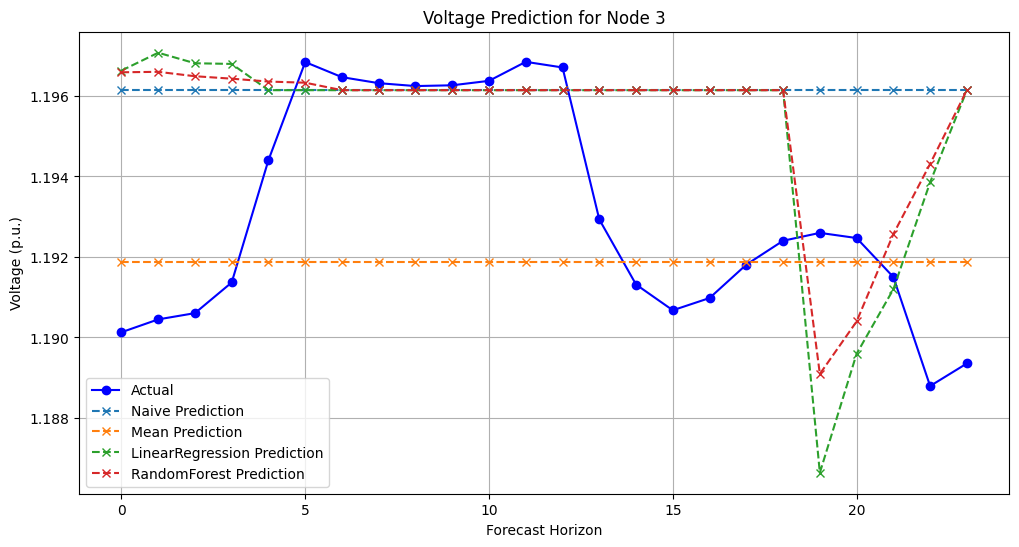

In [14]:
# Plot a sample node's voltage prediction
node_idx = 3  # First node
sample_idx = 3  # First test sample

plt.figure(figsize=(12, 6))
# Plot actual values
plt.plot(range(len(results['data']['y_test'][sample_idx])), 
            results['data']['y_test'][sample_idx][:, node_idx], 
            'b-', marker='o', label='Actual')

# Plot predictions for each model
for name, result in results['results'].items():
    plt.plot(range(len(result['predictions'][sample_idx])), 
                result['predictions'][sample_idx][:, node_idx], 
                '--', marker='x', label=f'{name} Prediction')

plt.xlabel('Forecast Horizon')
plt.ylabel('Voltage (p.u.)')
plt.title(f'Voltage Prediction for Node {results["node_ids"][node_idx]}')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
results

{'models': {'Naive': <__main__.NaiveModel at 0x12e363790>,
  'Mean': <__main__.MeanModel at 0x33782ccd0>,
  'LinearRegression': <__main__.MLModel at 0x37c687b50>,
  'RandomForest': <__main__.MLModel at 0x3b19a0f40>},
 'results': {'Naive': {'mae': 0.007464937223865636,
   'rmse': 0.013642376145863047,
   'predictions': array([[[1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434],
           [1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434],
           [1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434],
           ...,
           [1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434],
           [1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434],
           [1.09975122, 1.14007765, 1.11870027, ..., 1.16367485,
            1.14004312, 1.17328434]],
   
          [[1.11243991, 1.14738051, 1.12982367, ..